Este ejemplo aplica un **modelo de regresión logística** para la clasificación binaria en el conjunto de datos de flores *iris*.

Dado que este conjunto de datos considera tres clases diferentes (0.0 para iris setosa, 1.0 para iris versicolor y 2.0 para iris virginica), primero debemos reformular el problema como una **tarea de clasificación binaria**: centraremos la tarea en clasificar las nuevas instancias como *iris virginica* (clase positiva: 1) o *no iris virginica* (clase negativa: 0).

In [1]:
import numpy as np
from sklearn import datasets
iris = datasets.load_iris()
X = iris["data"][:,:]
y = (iris["target"] == 2).astype(int)

#OPCIONAL: Convert the iris dataset inton a Pandas DataFrame structure to view it nicely
import pandas as pd
dfiris = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])
dfiris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [2]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

Realicemos dos predicciones en dos instancias de flores especificadas manualmente:

In [3]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X, y)

log_reg.predict([[7.7, 3.1, 6.4, 1.8],
                 [5.8, 2.4, 4.6, 1.4]])

array([1, 0])

En este segundo ejemplo solo usaremos uno de los atributos, *petal width*, para predecir si un especímen de flor con una anchura de pétalo determinada sería clasificado como **iris virgínica** o no.

In [4]:
X = iris["data"][:, 3:] # For next predictions, consider only one attribute: petal width
log_reg = LogisticRegression()
log_reg.fit(X, y) # Train new model, this time with only one attribute in X

X_new = np.linspace(0, 3, 500).reshape(-1, 1)
y_probab = log_reg.predict_proba(X_new) #. Predicting probabilities on 500 instances with values distributed between 0 y 3
# y_probab # Show the 300 predictions of probabilities made. Each pair of values shows the probabilities (1-p, p).
         # Where p = probability of positive class

(np.float64(0.0), np.float64(3.0), np.float64(-0.02), np.float64(1.02))

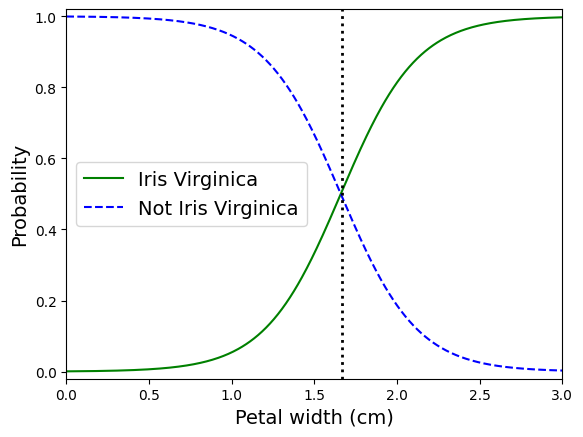

In [5]:
import matplotlib.pyplot as plt

# Show in a plot the probability of iris virginica as a function of the petal width (green solid line),
# The probability of not being iris virginica (blue dashed line), and the threshold value used by the model to separate both classes.
plt.plot(X_new, y_probab[:, 1], "g-", label="Iris Virginica")
plt.plot(X_new, y_probab[:, 0], "b--", label= "Not Iris Virginica")
decision_boundary = X_new[y_probab[:, 1] >= 0.5][0]
plt.plot([decision_boundary, decision_boundary], [-1, 2], "k:", linewidth=2)
plt.xlabel("Petal width (cm)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.legend(loc="center left", fontsize=14)
plt.axis([0, 3, -0.02, 1.02])

In [6]:
log_reg.predict([[1.75], [1.55]])

array([1, 0])

Tercer y último ejemplo, volviendo al **dataset de inicio** pero esta vez haciendo el debido particionado en conjuntos de entrenamiento y pruebas, para una evaluación más correcta.

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.25, random_state=0)

log_reg = LogisticRegression(max_iter=1000) # Use this hyperparameter to ensure convergence and avoid computing resource problems.
log_reg.fit(X_train, y_train)

test_predictions = log_reg.predict(X_test)

score = log_reg.score(X_test, y_test) # Calculate the model's predictive power on the test set as the % of correct predictions.
score

0.9736842105263158

**EJERCICIO PROPUESTO**
En el repositorio de datasets encontrarás el dataset Titanic. Construye un modelo clasificador binario basado en regresión logística para "predecir" si un pasajero sobrevivió o no al histórico accidente de 1912 en aguas del Atlántico Norte.

Deberás utilizar la variable *survived* como la etiqueta de clase, y realizar una selección cuidadosa y no muy ambiciosa de atributos predictores, preferiblemente numéricos en esta etapa del curso, para construir el modelo.

Una buena idea es entrenar varios modelos, con diferentes configuraciones de atributos seleccionados y/o proporciones del conjunto de entrenamiento y test, y analizar cómo afecta a los resultados de evaluar el % de aciertos sobre los datos de test.

In [8]:
titanic = titanic = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/titanic.csv")

In [9]:
y = titanic['Survived']
X = titanic[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
X.fillna(X.mean(), inplace=True)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Missing values in X after imputation:\n", X.isnull().sum())

Shape of X: (891, 5)
Shape of y: (891,)
Missing values in X after imputation:
 Pclass    0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64


/tmp/ipykernel_976/1793031475.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (668, 5)
Shape of X_test: (223, 5)
Shape of y_train: (668,)
Shape of y_test: (223,)


In [11]:
from sklearn.linear_model import LogisticRegression

log_reg_titanic = LogisticRegression(max_iter=1000)
log_reg_titanic.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [12]:
test_predictions = log_reg_titanic.predict(X_test)

score = log_reg_titanic.score(X_test, y_test)
score

0.7354260089686099